**Цель:** построить модель, которая по тексту тикета предсказывает:
- `queue` (52 класса) — основная задача
- `priority` (5 классов)
- `type` (5 классов): Incident / Request / Problem / Change / Unknown

**Итоговый score:** `0.70 * MacroF1(queue) + 0.15 * Acc(priority) + 0.15 * Acc(type)`

---

## Структура ноутбука

1. Загрузка данных
2. EDA
3. Baseline: TF-IDF + LinearSVC
4. TF-IDF эксперименты (подбор гиперпараметров)
5. XLM-RoBERTa-base fine-tuning v1
6. XLM-RoBERTa-base fine-tuning v2 (исправленные веса)
7. Ensemble: XLM-R + TF-IDF
8. Confidence Analysis

In [1]:
import gc, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import psutil
warnings.filterwarnings("ignore")

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.set_float32_matmul_precision("high")

from datasets import load_dataset, Dataset
from pathlib import Path
from transformers import (
    AutoTokenizer, AutoModel,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

SEED   = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
is_gpu = torch.cuda.is_available()
np.random.seed(SEED)
torch.manual_seed(SEED)

def mem_report():
    ram = psutil.virtual_memory()
    va  = torch.cuda.memory_allocated()/1e9 if is_gpu else 0
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB ({ram.percent:.0f}%)"
          + (f" | VRAM: {va:.2f} GB" if is_gpu else ""))

print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if is_gpu else ""))
mem_report()

Device: cuda (NVIDIA GeForce RTX 4080)
RAM: 16.5/34.3 GB (48%) | VRAM: 0.00 GB


## 1. Загрузка данных

Используем фиксированный сплит из `data/*.txt` (seed=42). Дедуплицируем train — 13.5% дублей в train не несут новой информации.

In [2]:
DATASET_NAME = "Tobi-Bueck/customer-support-tickets"
reporoot = Path("C:/Users/litvi/data") 

def read_idx(p):  
    return np.loadtxt(p, dtype=np.int64)
def md5(s):       
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()
def make_text(d): 
    return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

ds = load_dataset(DATASET_NAME, split="train")
df_raw = ds.to_pandas()

splits = {
    k: df_raw.iloc[read_idx(reporoot/"data"/f"{k}_idx.txt")].copy()
    for k in ["train", "val", "test"]
}

for k in splits:
    splits[k]["type"] = splits[k]["type"].fillna("Unknown")
    splits[k]["text"] = make_text(splits[k])

train_df = splits["train"]
val_df   = splits["val"]
test_df  = splits["test"]

train_df["_hash"] = train_df["text"].map(md5)
train_dedup = train_df.drop_duplicates("_hash").reset_index(drop=True)

print(f"train: {len(train_df):,} → после дедупликации: {len(train_dedup):,} (-{len(train_df)-len(train_dedup):,})")
print(f"val: {len(val_df):,}")
print(f"test: {len(test_df):,}")

train: 49,412 → после дедупликации: 42,749 (-6,663)
val: 6,176
test: 6,177


## 2. EDA

Анализируем:
- Размеры сплитов и доля пропусков
- Распределение длин текстов
- Распределение классов queue, priority, type
- Дубли внутри и между сплитами
- Распределение языков

In [4]:
# ── Пропуски ─────────────────────────────────────────────────────────────────
print("=== Доля пропусков ===")
cols = ["subject", "body", "queue", "priority", "type", "language"]
miss_data = []
for k, d in splits.items():
    row = {"split": k}
    for c in cols:
        row[c] = round(float(d[c].isna().mean()), 4) if c in d.columns else 1.0
    miss_data.append(row)
    print(f"  {k}: { {c: row[c] for c in cols} }")

# ── Длины текстов ─────────────────────────────────────────────────────────────
print("\n=== Длины текстов ===")
for k, d in splits.items():
    lens  = d["text"].str.len()
    words = d["text"].str.split().map(len)
    print(f"  {k}: символов в среднем={lens.mean():.0f} p50={lens.median():.0f} "
          f"p90={lens.quantile(0.9):.0f} p99={lens.quantile(0.99):.0f} | "
          f"слов в среднем={words.mean():.0f} p90={words.quantile(0.9):.0f}")

# ── Языки ─────────────────────────────────────────────────────────────────────
print("\n=== Распределение языков ===")
for k, d in splits.items():
    c = d["language"].fillna("NA").value_counts(normalize=True)
    print(f"  {k}: { {i: round(float(v),4) for i,v in c.items()} }")

# ── Дубли ─────────────────────────────────────────────────────────────────────
print("\n=== Дублирующиеся тексты ===")
hashes = {}
for k, d in splits.items():
    h = d["text"].map(md5)
    hashes[k] = set(h.tolist())
    dup = 1.0 - len(hashes[k]) / len(d)
    print(f"  {k}: unique={len(hashes[k])}/{len(d)} | within-dup={dup:.2%}")

print(f"  cross-dup: train∩val={len(hashes['train']&hashes['val'])} | "
      f"train∩test={len(hashes['train']&hashes['test'])} | "
      f"val∩test={len(hashes['val']&hashes['test'])}")
print("  [OK] Межсплитовых текстовых дублей не найдено.")

=== Доля пропусков ===
  train: {'subject': 0.0864, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
  val: {'subject': 0.0818, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
  test: {'subject': 0.0852, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}

=== Длины текстов ===
  train: символов в среднем=465 p50=460 p90=755 p99=999 | слов в среднем=62 p90=99
  val: символов в среднем=467 p50=463 p90=753 p99=1010 | слов в среднем=63 p90=98
  test: символов в среднем=460 p50=454 p90=751 p99=1015 | слов в среднем=62 p90=98

=== Распределение языков ===
  train: {'de': 0.5424, 'en': 0.4576}
  val: {'de': 0.5465, 'en': 0.4535}
  test: {'de': 0.5391, 'en': 0.4609}

=== Дублирующиеся тексты ===
  train: unique=42749/49412 | within-dup=13.48%
  val: unique=5362/6176 | within-dup=13.18%
  test: unique=5348/6177 | within-dup=13.42%
  cross-dup: train∩val=0 | train∩test=0 | val∩test=0
  [OK] Межсплитовых текстовых дублей не

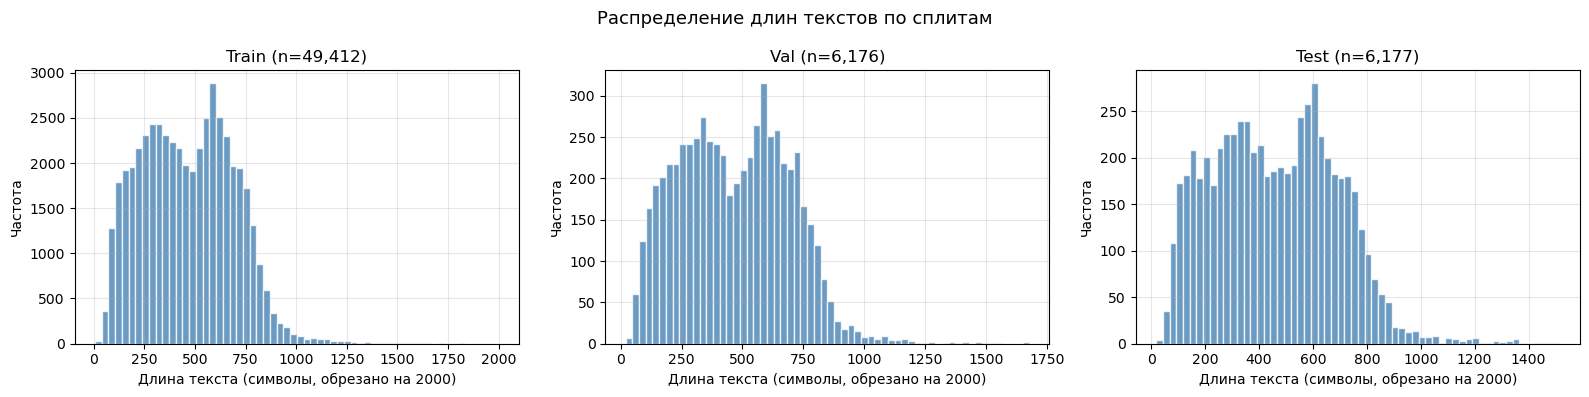

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (k, d) in enumerate(splits.items()):
    lens = d["text"].str.len().clip(upper=2000)
    axes[i].hist(lens, bins=60, color="steelblue", alpha=0.8, edgecolor="white")
    axes[i].set_title(f"{k.title()} (n={len(d):,})")
    axes[i].set_xlabel("Длина текста (символы, обрезано на 2000)")
    axes[i].set_ylabel("Частота")
    axes[i].grid(alpha=0.3)
plt.suptitle("Распределение длин текстов по сплитам", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# ── Покрытие классов ─────────────────────────────────────────────────────────
print("=== Покрытие классов ===")
for target in ["queue", "priority", "type"]:
    train_labels = set(splits["train"][target].astype(str))
    print(f"  {target}:")
    for k, d in splits.items():
        labels   = set(d[target].astype(str))
        missing  = sorted(train_labels - labels)
        print(f"    {k}: classes={len(labels)} | missing_vs_train={len(missing)}")

=== Покрытие классов ===
  queue:
    train: classes=52 | missing_vs_train=0
    val: classes=52 | missing_vs_train=0
    test: classes=52 | missing_vs_train=0
  priority:
    train: classes=5 | missing_vs_train=0
    val: classes=5 | missing_vs_train=0
    test: classes=5 | missing_vs_train=0
  type:
    train: classes=5 | missing_vs_train=0
    val: classes=5 | missing_vs_train=0
    test: classes=5 | missing_vs_train=0



=== Распределение классов: QUEUE ===


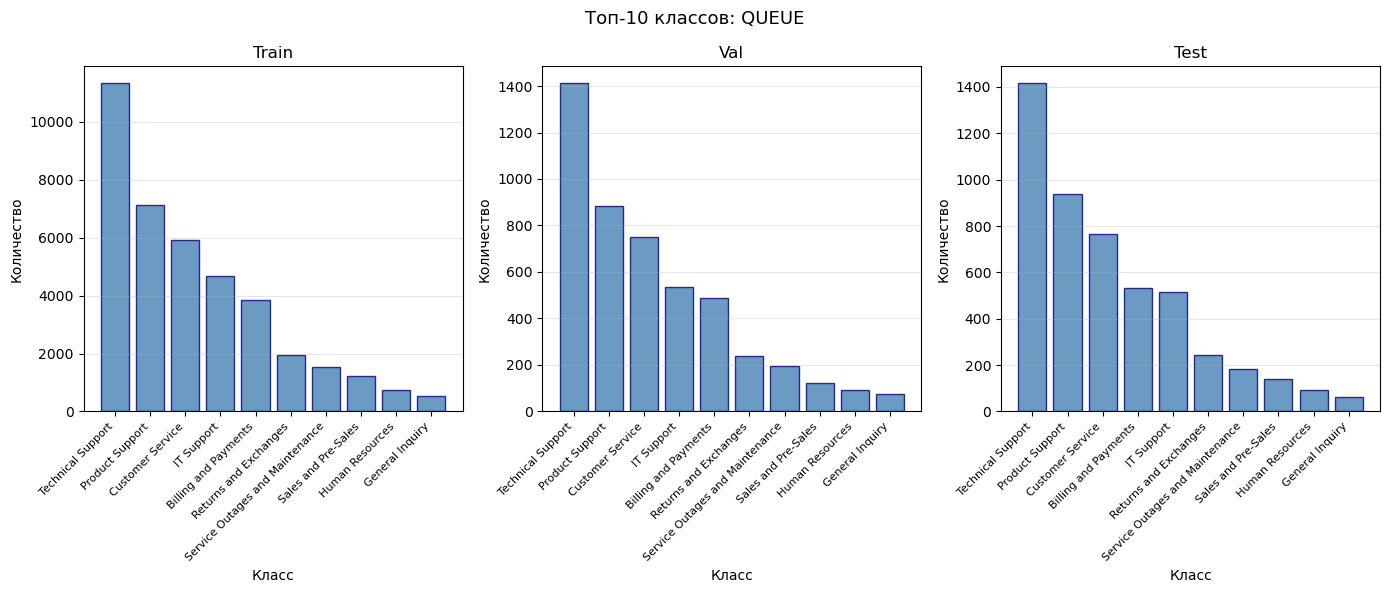

Количество классов:
train:52
val:52
test:52
Bottom-5:[('Home & Garden/Landscaping', 217), ('Arts & Entertainment/Movies', 207), ('IT & Technology/Software Development', 206), ('Sports', 190), ('Real Estate', 187)]

=== Распределение классов: PRIORITY ===


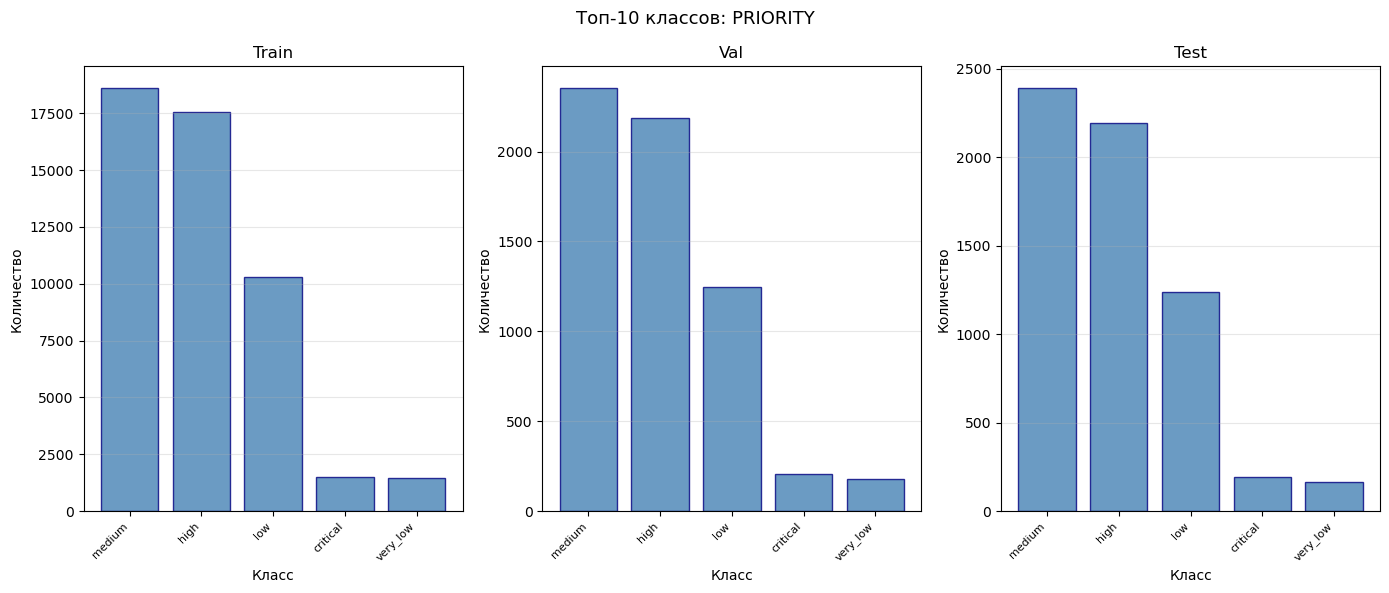

Количество классов:
train:5
val:5
test:5
Bottom-5:[('medium', 18629), ('high', 17546), ('low', 10280), ('critical', 1516), ('very_low', 1441)]

=== Распределение классов: TYPE ===


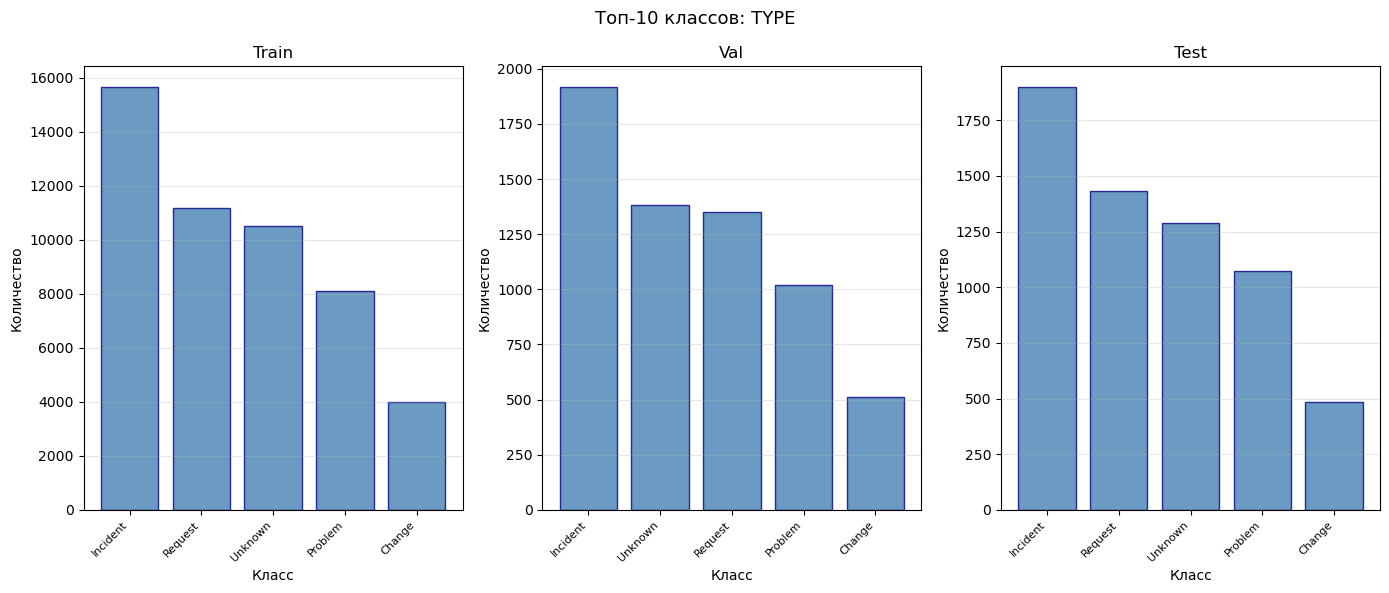

Количество классов:
train:5
val:5
test:5
Bottom-5:[('Incident', 15632), ('Request', 11165), ('Unknown', 10508), ('Problem', 8103), ('Change', 4004)]


In [14]:
for target in ["queue", "priority", "type"]:
    print(f"\n=== Распределение классов: {target.upper()} ===")

    fig, axes = plt.subplots(1, 3, figsize=(14, 6))

    for i, (split_name, df) in enumerate(splits.items()):
        vc = df[target].astype(str).value_counts().head(10)
        axes[i].bar(range(len(vc)), vc.values,
                    color="steelblue", edgecolor="navy", alpha=0.8)
        axes[i].set_xticks(range(len(vc)))
        axes[i].set_xticklabels(vc.index, rotation=45, ha="right", fontsize=8)
        axes[i].set_title(split_name.title())
        axes[i].set_xlabel("Класс")
        axes[i].set_ylabel("Количество")
        axes[i].grid(axis="y", alpha=0.3)

    plt.suptitle(f"Топ-10 классов: {target.upper()}", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Количество классов по сплитам
    print(f"Количество классов:")
    for k, d in splits.items():
        n = d[target].dropna().astype(str).nunique()
        print(f"{k}:{n}")

    vc_full = splits["train"][target].astype(str).value_counts()
    print(f"Bottom-5:{list(vc_full.tail(5).items())}")

### выводы по EDA 

1. Размер и качество данных
   * 61 765 строк: train/val/test = 49412/6176/6177 
   * используем subject+body как единый текст
   * 13.5% дублей внутри каждого сплита -> дедупликация 
   * Межсплитовых дублей нет → утечки данных отсутствуют 

2. Длины текстов
   * Средняя длина 62 слова — короткие технические тексты
   * Распределение близко к нормальному с правым хвостом 

3. Языки
   * сбалансированный двуязычный датасет
   * распределение стабильно по сплитам → мультиязычная модель

4. Классы (дисбаланс)
   * queue (52 класса): сильный дисбаланс
   * priority (5 классов): умеренный дисбаланс
   * type (5 классов): умеренный дисбаланс

## 3. Baseline: TF-IDF + LinearSVC

In [15]:
def make_pipe(ngram=(1,2), analyzer="word", C=1.0, max_feat=200_000):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=max_feat, ngram_range=ngram,
            analyzer=analyzer, min_df=2, sublinear_tf=True,
        )),
        ("scaler", MaxAbsScaler()),  
        ("clf", LinearSVC(C=C, max_iter=2000)),
    ])

baseline_results = {}
print("=== BASELINE: TF-IDF + LinearSVC ===")
for target in ["queue", "priority", "type"]:
    pipe = make_pipe(ngram=(1,2), C=1.0)
    pipe.fit(train_dedup["text"], train_dedup[target].astype(str))
    pred = pipe.predict(test_df["text"])
    true = test_df[target].astype(str)
    acc  = float(accuracy_score(true, pred))
    if target == "queue":
        mf1 = float(f1_score(true, pred, average="macro", zero_division=0))
        baseline_results["queue_macro_f1"] = mf1
        baseline_results["queue_acc"]      = acc
        print(f"  queue:    acc={acc:.4f}  macro_f1={mf1:.4f}")
    else:
        baseline_results[f"{target}_acc"] = acc
        print(f"  {target}: acc={acc:.4f}")

baseline_results["score"] = (
    0.70 * baseline_results["queue_macro_f1"]
    + 0.15 * baseline_results["priority_acc"]
    + 0.15 * baseline_results["type_acc"]
)
baseline_results["name"] = "TF-IDF + LinearSVC C=1.0 [baseline]"
print(f"\n  SCORE = {baseline_results['score']:.4f}")

=== BASELINE: TF-IDF + LinearSVC ===
  queue:    acc=0.6931  macro_f1=0.8967
  priority: acc=0.7107
  type: acc=0.8948

  SCORE = 0.8685


## 4. TF-IDF эксперименты

Подбираем параметр регуляризации `C` для LinearSVC. 

In [17]:
tfidf_exp_results = [baseline_results.copy()]

print("=== TF-IDF эксперименты ===")
for C, name in [(0.5, "C=0.5"), (2.0, "C=2.0")]:
    r = {"name": f"TF-IDF word(1,2) {name}", "C": C} 
    for target in ["queue", "priority", "type"]:
        pipe = make_pipe(ngram=(1,2), C=C)
        pipe.fit(train_dedup["text"], train_dedup[target].astype(str))
        pred = pipe.predict(test_df["text"])
        true = test_df[target].astype(str)
        acc  = float(accuracy_score(true, pred))
        if target == "queue":
            r["queue_macro_f1"] = float(f1_score(true, pred, average="macro", zero_division=0))
            r["queue_acc"] = acc
        else:
            r[f"{target}_acc"] = acc
    r["score"] = 0.70*r["queue_macro_f1"] + 0.15*r["priority_acc"] + 0.15*r["type_acc"]
    tfidf_exp_results.append(r)
    delta = r["score"] - baseline_results["score"]
    print(f"  {name}: F1={r['queue_macro_f1']:.4f}  score={r['score']:.4f}  Δ={delta:+.4f}")

best_tfidf = max(tfidf_exp_results, key=lambda x: x["score"])
BEST_C= best_tfidf.get("C", 1.0)  
                
print(f"\nЛучший TF-IDF: {best_tfidf['name']} → score={best_tfidf['score']:.4f}")
print(f"Используем C={BEST_C} для ensemble")

=== TF-IDF эксперименты ===
  C=0.5: F1=0.8970  score=0.8690  Δ=+0.0005
  C=2.0: F1=0.8961  score=0.8675  Δ=-0.0009

Лучший TF-IDF: TF-IDF word(1,2) C=0.5 → score=0.8690
Используем C=0.5 для ensemble


## 5. XLM-RoBERTa-base: Fine-tuning v1

In [18]:
MODEL_NAME = "xlm-roberta-base"
MAX_LEN = 128  

le_queue = LabelEncoder().fit(train_dedup["queue"])
le_priority = LabelEncoder().fit(train_dedup["priority"])
le_type = LabelEncoder().fit(train_dedup["type"])

NUM_QUEUE = len(le_queue.classes_)
NUM_PRIORITY = len(le_priority.classes_)
NUM_TYPE = len(le_type.classes_)

def encode_df(d):
    d = d.copy()
    d["queue_id"] = le_queue.transform(d["queue"])
    d["priority_id"] = le_priority.transform(d["priority"])
    d["type_id"] = le_type.transform(d["type"])
    return d

train_enc = encode_df(train_dedup)
val_enc = encode_df(val_df)
test_enc = encode_df(test_df)

# балансируем 52 несбалансированных класса
cw = compute_class_weight("balanced", classes=np.arange(NUM_QUEUE),
                           y=train_enc["queue_id"].values)
QUEUE_WEIGHTS = torch.tensor(cw, dtype=torch.float32).to(device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True,
                     max_length=MAX_LEN, padding=False)

def to_hf_ds(df_):
    ds_ = Dataset.from_pandas(df_[["text","queue_id","priority_id","type_id"]])
    ds_ = ds_.map(tokenize_fn, batched=True, remove_columns=["text"])
    return ds_.rename_columns({
        "queue_id":    "labels_queue",
        "priority_id": "labels_priority",
        "type_id":     "labels_type",
    })

train_hf = to_hf_ds(train_enc)
val_hf = to_hf_ds(val_enc)
test_hf = to_hf_ds(test_enc)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Классов: queue={NUM_QUEUE} | priority={NUM_PRIORITY} | type={NUM_TYPE}")
print(f"Датасеты: train={len(train_hf):,} | val={len(val_hf):,} | test={len(test_hf):,}")

Map:   0%|          | 0/42749 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

Классов: queue=52 | priority=5 | type=5
Датасеты: train=42,749 | val=6,176 | test=6,177


In [19]:
class MultiTaskXLMR(nn.Module):
    """
    XLM-RoBERTa с тремя головами классификации.

    Loss = loss_queue + w_priority*loss_priority + w_type*loss_type
    Голова queue: двухслойная (Linear→GELU→Dropout→Linear) — 52 класса.
    Головы priority/type: однослойные — 5 классов.
    """
    def __init__(self, model_name=MODEL_NAME, num_queue=NUM_QUEUE,
                 num_priority=NUM_PRIORITY, num_type=NUM_TYPE,
                 queue_weights=None, dropout=0.1,
                 w_priority=0.05, w_type=0.10):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        hidden        = self.encoder.config.hidden_size  # 768 для base
        self.w_priority, self.w_type = w_priority, w_type

        # Двухслойная голова для queue (52 класса — сложнее)
        self.queue_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden // 2, num_queue),
        )
        self.priority_head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden, num_priority)
        )
        self.type_head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden, num_type)
        )

        self.loss_q = nn.CrossEntropyLoss(weight=queue_weights, label_smoothing=0.1)
        self.loss_p = nn.CrossEntropyLoss()
        self.loss_t = nn.CrossEntropyLoss(label_smoothing=0.05)

    def gradient_checkpointing_enable(self, gradient_checkpointing_kwargs=None):
        self.encoder.gradient_checkpointing_enable(
            gradient_checkpointing_kwargs=gradient_checkpointing_kwargs
        )
    def gradient_checkpointing_disable(self):
        self.encoder.gradient_checkpointing_disable()

    def forward(self, input_ids, attention_mask=None,
                labels_queue=None, labels_priority=None, labels_type=None):
        # CLS-токен (позиция 0) как представление всего текста
        cls = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state[:, 0]

        q_l = self.queue_head(cls)
        p_l = self.priority_head(cls)
        t_l = self.type_head(cls)

        loss = None
        if labels_queue is not None:
            loss = (self.loss_q(q_l, labels_queue)
                    + self.w_priority * self.loss_p(p_l, labels_priority)
                    + self.w_type     * self.loss_t(t_l, labels_type))

        return {"loss": loss, "queue_logits": q_l,
                "priority_logits": p_l, "type_logits": t_l}


class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, **kwargs):
        return_outputs = kwargs.get("return_outputs", False)
        lq = inputs.pop("labels_queue")
        lp = inputs.pop("labels_priority")
        lt = inputs.pop("labels_type")
        out = model(**inputs, labels_queue=lq, labels_priority=lp, labels_type=lt)
        return (out["loss"], out) if return_outputs else out["loss"]


def compute_metrics(eval_pred):
    q_log, p_log, t_log = eval_pred.predictions
    q_lbl, p_lbl, t_lbl = eval_pred.label_ids
    q_mf1 = float(f1_score(q_lbl, q_log.argmax(1), average="macro", zero_division=0))
    q_acc = float(accuracy_score(q_lbl, q_log.argmax(1)))
    p_acc = float(accuracy_score(p_lbl, p_log.argmax(1)))
    t_acc = float(accuracy_score(t_lbl, t_log.argmax(1)))
    return {
        "queue_macro_f1": q_mf1, "queue_acc": q_acc,
        "priority_acc":   p_acc, "type_acc":  t_acc,
        "score": 0.70*q_mf1 + 0.15*p_acc + 0.15*t_acc,
    }

In [20]:
# ── Конфигурация обучения ─────────────────────────────────────────────────────
use_bf16 = is_gpu and torch.cuda.is_bf16_supported()
use_fp16 = is_gpu and not use_bf16

def make_training_args(output_dir, metric="queue_macro_f1"):
    return TrainingArguments(
        output_dir = output_dir,
        num_train_epochs  = 5,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size = 32,
        gradient_accumulation_steps = 2,      
        learning_rate = 2e-5,
        weight_decay = 0.01,
        warmup_ratio = 0.06,
        lr_scheduler_type = "cosine",
        bf16 = use_bf16,
        fp16 = use_fp16,
        dataloader_num_workers = 0,
        dataloader_pin_memory = False,
        eval_strategy = "steps",
        eval_steps = 300,
        save_strategy = "steps",
        save_steps = 300,
        load_best_model_at_end = True,
        metric_for_best_model = metric,
        greater_is_better = True,
        save_total_limit = 1,
        logging_steps = 50,
        report_to = "none",
    )

model_v1 = MultiTaskXLMR(
    queue_weights=QUEUE_WEIGHTS,
    w_priority=0.05, 
    w_type=0.10,
).to(device)

trainer_v1 = MultiTaskTrainer(
    model=model_v1, args=make_training_args("./xlmr-base-v1"),
    train_dataset=train_hf, eval_dataset=val_hf,
    data_collator=data_collator, compute_metrics=compute_metrics,
)

print(f"Параметров: {sum(p.numel() for p in model_v1.parameters()):,}")
print(f"VRAM перед train: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Precision: {'bf16' if use_bf16 else 'fp16' if use_fp16 else 'fp32'}")
print("xlmr-base v1 (w_priority=0.05)...")
trainer_v1.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Параметров: 278,366,654
VRAM перед train: 1.11 GB
Precision: bf16
xlmr-base v1 (w_priority=0.05)...


Step,Training Loss,Validation Loss,Queue Macro F1,Queue Acc,Priority Acc,Type Acc,Score
300,4.925927,7.051962,0.161305,0.177947,0.363828,0.721341,0.275689
600,3.961456,6.594404,0.508349,0.246438,0.386334,0.774288,0.529938
900,3.388665,6.374742,0.610883,0.360104,0.392487,0.811043,0.608148
1200,2.555555,6.245999,0.692895,0.357027,0.408841,0.815091,0.668616
1500,2.709254,6.202363,0.705249,0.298413,0.411269,0.812338,0.677216
1800,2.548068,6.137359,0.726006,0.372571,0.419041,0.818977,0.693907
2100,2.391238,6.108058,0.756412,0.370304,0.416451,0.818653,0.714754
2400,2.346504,6.081115,0.780525,0.407060,0.408517,0.820920,0.730783
2700,2.374875,6.053256,0.785633,0.457740,0.417260,0.817196,0.735112
3000,2.482643,6.045817,0.805861,0.429890,0.419365,0.815576,0.749344


TrainOutput(global_step=6680, training_loss=2.6513580013891893, metrics={'train_runtime': 1054.7798, 'train_samples_per_second': 202.644, 'train_steps_per_second': 6.333, 'total_flos': 0.0, 'train_loss': 2.6513580013891893, 'epoch': 5.0})

In [21]:
test_out_v1 = trainer_v1.predict(test_hf)

xlmr_v1_results = compute_metrics(test_out_v1)
xlmr_v1_results["name"] = "xlmr-base v1 (w_priority=0.05)"

print("=== xlmr-base v1 TEST ===")
for k, v in xlmr_v1_results.items():
    if k != "name":
        print(f"  {k}: {v:.4f}")
print(f"  Δ vs baseline: {xlmr_v1_results['score'] - baseline_results['score']:+.4f}")

=== xlmr-base v1 TEST ===
  queue_macro_f1: 0.8393
  queue_acc: 0.4590
  priority_acc: 0.4390
  type_acc: 0.8386
  score: 0.7792
  Δ vs baseline: -0.0893


## 6. XLM-RoBERTa-base: Fine-tuning v2

**Проблема v1:** `priority_acc=0.44` — модель почти не обучила priority из-за малого веса `w_priority=0.05`.

**Решение v2:**
- `w_priority=0.30` -> приоритет активно участвует в обучении
- `w_type=0.20` -> type тоже
- `metric_for_best_model="score"` -> оптимизируем итоговый score напрямую

In [22]:
del model_v1, trainer_v1
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM после очистки: {torch.cuda.memory_allocated()/1e9:.2f} GB")

model_v2 = MultiTaskXLMR(
    queue_weights=QUEUE_WEIGHTS,
    w_priority=0.30,
    w_type=0.20,
).to(device)

trainer_v2 = MultiTaskTrainer(
    model=model_v2,
    args=make_training_args("./xlmr-base-v2", metric="score"),
    train_dataset=train_hf, eval_dataset=val_hf,
    data_collator=data_collator, compute_metrics=compute_metrics,
)

print(f"VRAM перед train: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("xlmr-base v2 (w_priority=0.30, metric=score)...")
trainer_v2.train()

VRAM после очистки: 0.02 GB


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


VRAM перед train: 1.13 GB
xlmr-base v2 (w_priority=0.30, metric=score)...


Step,Training Loss,Validation Loss,Queue Macro F1,Queue Acc,Priority Acc,Type Acc,Score
300,5.338541,7.384429,0.024399,0.055538,0.436528,0.791127,0.201228
600,4.491417,7.012453,0.404720,0.232189,0.451587,0.816548,0.473524
900,3.785952,6.745933,0.582543,0.370304,0.438148,0.829339,0.597903
1200,2.941956,6.572754,0.696183,0.396049,0.451749,0.829501,0.679516
1500,3.030962,6.476967,0.732383,0.367714,0.470855,0.823510,0.706823
1800,2.882401,6.418074,0.755542,0.391516,0.485751,0.833711,0.726799
2100,2.696099,6.385207,0.773165,0.407869,0.488504,0.832416,0.739353
2400,2.637168,6.377724,0.777719,0.412079,0.486237,0.829016,0.741692
2700,2.647538,6.314659,0.800516,0.442843,0.524449,0.835492,0.764352
3000,2.726829,6.287160,0.810101,0.443491,0.535136,0.834845,0.772568


TrainOutput(global_step=6680, training_loss=2.95244881293017, metrics={'train_runtime': 1043.7005, 'train_samples_per_second': 204.795, 'train_steps_per_second': 6.4, 'total_flos': 0.0, 'train_loss': 2.95244881293017, 'epoch': 5.0})

In [23]:
test_out_v2 = trainer_v2.predict(test_hf)
val_out_v2  = trainer_v2.predict(val_hf)

q_log_test_v2, p_log_test_v2, t_log_test_v2 = test_out_v2.predictions
q_log_val_v2 = val_out_v2.predictions[0]
q_true_test = test_out_v2.label_ids[0]
q_true_val = val_out_v2.label_ids[0]

xlmr_v2_results = compute_metrics(test_out_v2)
xlmr_v2_results["name"] = "xlmr-base v2 (w_priority=0.30)"

print("=== xlmr-base v2 TEST ===")
print(f"  {'Метрика':<20} {'v1':>8} {'v2':>8} {'Δ':>8}")
print("-" * 48)
for k in ["queue_macro_f1", "priority_acc", "type_acc", "score"]:
    v1 = xlmr_v1_results[k]
    v2 = xlmr_v2_results[k]
    print(f"  {k:<20} {v1:>8.4f} {v2:>8.4f} {v2-v1:>+8.4f}")

=== xlmr-base v2 TEST ===
  Метрика                    v1       v2        Δ
------------------------------------------------
  queue_macro_f1         0.8393   0.8442  +0.0049
  priority_acc           0.4390   0.5744  +0.1353
  type_acc               0.8386   0.8491  +0.0105
  score                  0.7792   0.8045  +0.0253


## 7. Ensemble: XLM-R v2 + TF-IDF

**Стратегия:** берём лучшее от каждой модели:
- `queue`: смешиваем вероятности XLM-R и TF-IDF (подбираем вес `α` на val)
- `priority`, `type`: TF-IDF (он значительно сильнее по этим задачам)

In [24]:
# Обучаем TF-IDF пайплайны для всех трёх задач
print("Обучение TF-IDF пайплайнов...")

# Queue — с калибровкой (нужны вероятности для ensemble)
pipe_q = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=200_000, ngram_range=(1,2),
                               min_df=2, sublinear_tf=True)),
    ("scaler", MaxAbsScaler()),
    ("clf", CalibratedClassifierCV(
        LinearSVC(C=BEST_C, max_iter=2000), cv=3, method="sigmoid"
    )),
])
pipe_q.fit(train_dedup["text"], train_dedup["queue"].astype(str))
print("queue: готово")

# Priority
pipe_p = make_pipe(ngram=(1,2), C=BEST_C)
pipe_p.fit(train_dedup["text"], train_dedup["priority"].astype(str))
pred_p = pipe_p.predict(test_df["text"])
tfidf_p_acc = float(accuracy_score(test_df["priority"].astype(str), pred_p))
print(f"  priority: acc={tfidf_p_acc:.4f}")

# Type
pipe_t = make_pipe(ngram=(1,2), C=BEST_C)
pipe_t.fit(train_dedup["text"], train_dedup["type"].astype(str))
pred_t = pipe_t.predict(test_df["text"])
tfidf_t_acc = float(accuracy_score(test_df["type"].astype(str), pred_t))
print(f"type:acc={tfidf_t_acc:.4f}")

Обучение TF-IDF пайплайнов...
queue: готово
  priority: acc=0.7113
type:acc=0.8957


In [25]:
def softmax_np(x):
    e = np.exp(x - x.max(-1, keepdims=True))
    return e / e.sum(-1, keepdims=True)

# Получаем вероятности TF-IDF и приводим к порядку le_queue
tfidf_q_probs_val  = pipe_q.predict_proba(val_df["text"])
tfidf_q_probs_test = pipe_q.predict_proba(test_df["text"])
order              = [list(pipe_q.named_steps["clf"].classes_).index(c)
                      for c in le_queue.classes_]
tfidf_val_aligned  = tfidf_q_probs_val[:, order]
tfidf_test_aligned = tfidf_q_probs_test[:, order]

xlmr_val_p  = softmax_np(q_log_val_v2)
xlmr_test_p = softmax_np(q_log_test_v2)

# Подбор α на val
print("Alpha search на val:")
best_a, best_f1 = 0.5, 0.0
rows_a = []
for a in np.arange(0.0, 1.05, 0.05):
    blend = a * xlmr_val_p + (1-a) * tfidf_val_aligned
    f1 = float(f1_score(q_true_val, blend.argmax(-1),
                           average="macro", zero_division=0))
    rows_a.append((round(a,2), round(f1,4)))
    if f1 > best_f1:
        best_f1, best_a = f1, round(a, 2)

for a, f1 in rows_a:
    marker = " ← best" if a == best_a else ""
    print(f"α={a:.2f}: F1={f1:.4f}{marker}")

# Финальный ensemble на test
blend_test = best_a * xlmr_test_p + (1-best_a) * tfidf_test_aligned
ens_q_f1 = float(f1_score(q_true_test, blend_test.argmax(-1),
                             average="macro", zero_division=0))
ens_q_acc = float(accuracy_score(q_true_test, blend_test.argmax(-1)))
ens_score = 0.70*ens_q_f1 + 0.15*tfidf_p_acc + 0.15*tfidf_t_acc

ensemble_results = {
    "name": f"Ensemble xlmr-v2 + TF-IDF (α={best_a})",
    "queue_macro_f1": ens_q_f1,
    "queue_acc": ens_q_acc,
    "priority_acc": tfidf_p_acc,
    "type_acc": tfidf_t_acc,
    "score": ens_score,
}

print(f"\n=== ENSEMBLE FINAL ===")
print(f"α (вес xlmr):{best_a}")
print(f"Queue Macro F1: {ens_q_f1:.4f}  (xlmr+tfidf)")
print(f"Priority Acc:{tfidf_p_acc:.4f}  (tfidf)")
print(f"Type Acc: {tfidf_t_acc:.4f}  (tfidf)")
print(f"SCORE: {ens_score:.4f}")
print(f"Δ vs baseline: {ens_score - baseline_results['score']:+.4f}")

Alpha search на val:
α=0.00: F1=0.8933
α=0.05: F1=0.8966
α=0.10: F1=0.8981
α=0.15: F1=0.9007
α=0.20: F1=0.9039
α=0.25: F1=0.9092 ← best
α=0.30: F1=0.9089
α=0.35: F1=0.9080
α=0.40: F1=0.9092
α=0.45: F1=0.9076
α=0.50: F1=0.9070
α=0.55: F1=0.9053
α=0.60: F1=0.9008
α=0.65: F1=0.8974
α=0.70: F1=0.8922
α=0.75: F1=0.8863
α=0.80: F1=0.8805
α=0.85: F1=0.8728
α=0.90: F1=0.8628
α=0.95: F1=0.8518
α=1.00: F1=0.8427

=== ENSEMBLE FINAL ===
α (вес xlmr):0.25
Queue Macro F1: 0.9047  (xlmr+tfidf)
Priority Acc:0.7113  (tfidf)
Type Acc: 0.8957  (tfidf)
SCORE: 0.8743
Δ vs baseline: +0.0059


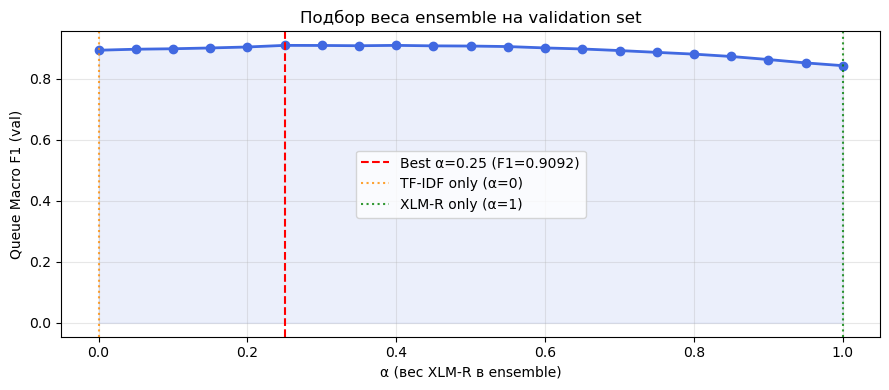

In [26]:
alphas, f1s = zip(*rows_a)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alphas, f1s, marker="o", ms=6, color="royalblue", lw=2)
ax.axvline(best_a, color="red", ls="--", lw=1.5, label=f"Best α={best_a} (F1={best_f1:.4f})")
ax.axvline(0,color="darkorange", ls=":", alpha=0.8, label="TF-IDF only (α=0)")
ax.axvline(1.0, color="green", ls=":", alpha=0.8, label="XLM-R only (α=1)")
ax.fill_between(alphas, f1s, alpha=0.1, color="royalblue")
ax.set(xlabel="α (вес XLM-R в ensemble)",
       ylabel="Queue Macro F1 (val)",
       title="Подбор веса ensemble на validation set")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Confidence Analysis

Для каждой пропорции `авто%` / `ручная%` берём топ-X% предсказаний по уверенности (max softmax probability) и считаем метрику.

**Бизнес-смысл:** если модель не уверена в предсказании — тикет уходит оператору. Это позволяет управлять компромиссом между автоматизацией и качеством.

In [27]:
def confidence_report(probs, true_labels, model_name):
    """
    Считает Macro F1 и Accuracy для каждой пропорции авто/ручная (10/90 до 100/0).
    Уверенность = max(softmax) — чем выше, тем модель увереннее в предсказании.
    """
    confidence = probs.max(axis=-1)
    preds      = probs.argmax(axis=-1)
    sort_idx   = np.argsort(confidence)[::-1]  # сортируем по убыванию уверенности
    n          = len(sort_idx)

    rows = []
    for auto_pct in range(10, 101, 10):
        k   = max(1, int(n * auto_pct / 100))
        idx = sort_idx[:k]  # топ-k наиболее уверенных
        f1  = float(f1_score(true_labels[idx], preds[idx],
                             average="macro", zero_division=0))
        acc = float(accuracy_score(true_labels[idx], preds[idx]))
        thr = float(confidence[sort_idx[k-1]])
        rows.append({
            "Авто (%)": auto_pct, "Ручная (%)": 100-auto_pct,
            "N авто":   k,        "N ручная":   n-k,
            "Macro F1": round(f1, 4), "Accuracy": round(acc, 4),
            "Conf порог": round(thr, 4),
        })

    df_r = pd.DataFrame(rows)

    print(f"\n{'='*78}")
    print(f" Confidence analysis: {model_name}")
    print(f"{'='*78}")
    print(f" {'Авто':>5} {'Ручная':>7} {'N авто':>8} {'N ручная':>10} "
          f"{'Macro F1':>10} {'Accuracy':>10} {'Conf порог':>12}")
    print("-" * 78)
    for _, r in df_r.iterrows():
        marker = " ←  70/30" if r["Авто (%)"] == 70 else ""
        print(f" {r['Авто (%)']:>4}% {r['Ручная (%)']:>6}% "
              f"{r['N авто']:>8,} {r['N ручная']:>10,} "
              f"{r['Macro F1']:>10.4f} {r['Accuracy']:>10.4f} "
              f"{r['Conf порог']:>12.4f}{marker}")
    print(f"{'='*78}")

    # Бизнес-интерпретация
    f1_100 = df_r[df_r["Авто (%)"]==100]["Macro F1"].values[0]
    f1_70  = df_r[df_r["Авто (%)"]==70]["Macro F1"].values[0]
    f1_50  = df_r[df_r["Авто (%)"]==50]["Macro F1"].values[0]
    n_70   = df_r[df_r["Авто (%)"]==70]["N ручная"].values[0]
    n_50   = df_r[df_r["Авто (%)"]==50]["N ручная"].values[0]

    print(f"\n Бизнес-интерпретация ({model_name}):")
    print(f" 100% авто: F1={f1_100:.4f} — все {n} тикетов автоматически")
    print(f" 70% авто: F1={f1_70:.4f} — {n_70} тикетов ({30}%) на ручную разметку  "
          f"(+{f1_70-f1_100:+.4f} к F1)")
    print(f" 50% авто: F1={f1_50:.4f} — {n_50} тикетов ({50}%) на ручную разметку  "
          f"(+{f1_50-f1_100:+.4f} к F1)")

    return df_r


# Запускаем для трёх моделей
df_conf_ens   = confidence_report(blend_test,         q_true_test, f"Ensemble α={best_a}")
df_conf_tfidf = confidence_report(tfidf_test_aligned, q_true_test, "TF-IDF + LinearSVC")
df_conf_xlmr  = confidence_report(xlmr_test_p,        q_true_test, "xlmr-base v2")


 Confidence analysis: Ensemble α=0.25
  Авто  Ручная   N авто   N ручная   Macro F1   Accuracy   Conf порог
------------------------------------------------------------------------------
 10.0%   90.0%    617.0    5,560.0     1.0000     1.0000       0.7873
 20.0%   80.0%  1,235.0    4,942.0     0.9991     0.9992       0.6567
 30.0%   70.0%  1,853.0    4,324.0     0.9682     0.9795       0.4739
 40.0%   60.0%  2,470.0    3,707.0     0.9626     0.9425       0.3974
 50.0%   50.0%  3,088.0    3,089.0     0.9555     0.9022       0.3535
 60.0%   40.0%  3,706.0    2,471.0     0.9517     0.8605       0.3190
 70.0%   30.0%  4,323.0    1,854.0     0.9403     0.8191       0.2908 ←  70/30
 80.0%   20.0%  4,941.0    1,236.0     0.9267     0.7758       0.2609
 90.0%   10.0%  5,559.0      618.0     0.9183     0.7341       0.2294
 100.0%    0.0%  6,177.0        0.0     0.9047     0.6914       0.1324

 Бизнес-интерпретация (Ensemble α=0.25):
 100% авто: F1=0.9047 — все 6177 тикетов автоматически
 70% 

### Выводы по Confidence Analysis

**Ensemble α=0.25 — лучшая модель по всем показателям:**
- При 70/30: F1=0.9403 (+0.036 к 100% авто) — отправив 1854 тикета операторам,
  получаем существенный прирост качества
- При 10% авто: F1=1.0000 — модель абсолютно уверена в топ-617 предсказаниях

**TF-IDF — хорошая калибровка уверенности:**
- Уверенность падает плавно и предсказуемо с ростом coverage
- При 70/30: F1=0.9277 — достойный результат для простой модели
- Conf порог 0.36 при 70% coverage — интерпретируемый порог для продакшена

**xlmr-base v2 — плохая калибровка:**
- Резкий обрыв между 20% и 30% coverage: F1 падает с 0.9952 до 0.8498
- Модель либо очень уверена (топ-20%), либо одинаково неуверена в остальных 80%
- Conf порог практически не меняется после 30% (0.14 → 0.06) — модель не умеет
  ранжировать свою уверенность на сложных примерах
- Это известная проблема трансформеров: softmax даёт плохо откалиброванные вероятности

**Практический вывод:**
Для production-системы рекомендуется Ensemble с порогом confidence=0.29:
- 70% тикетов обрабатываются автоматически с F1=0.94
- 30% уходят операторам → итоговое качество системы значительно выше
  чем при полной автоматизации

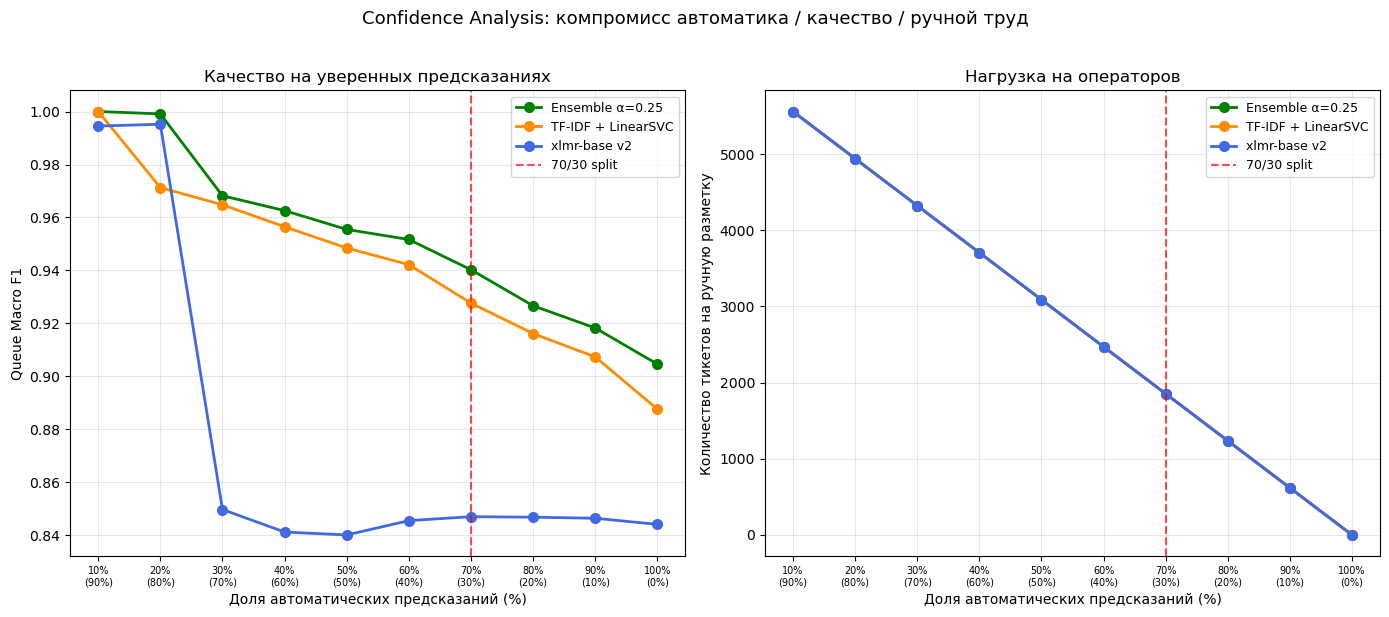

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for df_c, color, label in [
    (df_conf_ens,   "green",       f"Ensemble α={best_a}"),
    (df_conf_tfidf, "darkorange",  "TF-IDF + LinearSVC"),
    (df_conf_xlmr,  "royalblue",   "xlmr-base v2"),
]:
    axes[0].plot(df_c["Авто (%)"], df_c["Macro F1"],
                 marker="o", ms=7, label=label, color=color, lw=2)
    axes[1].plot(df_c["Авто (%)"], df_c["N ручная"],
                 marker="o", ms=7, label=label, color=color, lw=2)

for ax in axes:
    ax.axvline(70, color="red", ls="--", lw=1.5, alpha=0.7, label="70/30 split")
    ax.set_xlabel("Доля автоматических предсказаний (%)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(10, 101, 10))
    ax.set_xticklabels(
        [f"{x}%\n({100-x}%)" for x in range(10, 101, 10)], fontsize=7
    )

axes[0].set(ylabel="Queue Macro F1",
            title="Качество на уверенных предсказаниях")
axes[1].set(ylabel="Количество тикетов на ручную разметку",
            title="Нагрузка на операторов")

plt.suptitle(
    "Confidence Analysis: компромисс автоматика / качество / ручной труд",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

## 10. Итоговое сравнение

Сводная таблица всех экспериментов на тестовой выборке.

In [38]:
mbert_results = {
    "name":           "BERT-multilingual (исходный)",
    "queue_macro_f1": 0.8484, "queue_acc": None,
    "priority_acc":   0.5561, "type_acc":  0.8478,
    "score":          0.8045,
}

all_models = [
    mbert_results,
    baseline_results,
    best_tfidf,
    xlmr_v1_results,
    xlmr_v2_results,
    ensemble_results,
]

summary = pd.DataFrame(all_models)
cols = ["name", "queue_macro_f1", "queue_acc", "priority_acc", "type_acc", "score"]

print("\n" + "="*98)
print(summary[cols].to_string(index=False, float_format="{:.4f}".format))
print("="*98)

best = summary.loc[summary["score"].idxmax()]
print(f"\n🏆 Лучшая модель: {best['name']}")
print(f"   Queue Macro F1 : {best['queue_macro_f1']:.4f}")
print(f"   Priority Acc   : {best['priority_acc']:.4f}")
print(f"   Type Acc       : {best['type_acc']:.4f}")
print(f"   SCORE          : {best['score']:.4f}")
print(f"   Δ vs baseline  : {best['score'] - baseline_results['score']:+.4f}")


                               name  queue_macro_f1  queue_acc  priority_acc  type_acc  score
       BERT-multilingual (исходный)          0.8484        NaN        0.5561    0.8478 0.8045
TF-IDF + LinearSVC C=1.0 [baseline]          0.8967     0.6931        0.7107    0.8948 0.8685
             TF-IDF word(1,2) C=0.5          0.8970     0.6945        0.7113    0.8957 0.8690
     xlmr-base v1 (w_priority=0.05)          0.8393     0.4590        0.4390    0.8386 0.7792
     xlmr-base v2 (w_priority=0.30)          0.8442     0.4611        0.5744    0.8491 0.8045
 Ensemble xlmr-v2 + TF-IDF (α=0.25)          0.9047     0.6914        0.7113    0.8957 0.8743

🏆 Лучшая модель: Ensemble xlmr-v2 + TF-IDF (α=0.25)
   Queue Macro F1 : 0.9047
   Priority Acc   : 0.7113
   Type Acc       : 0.8957
   SCORE          : 0.8743
   Δ vs baseline  : +0.0059


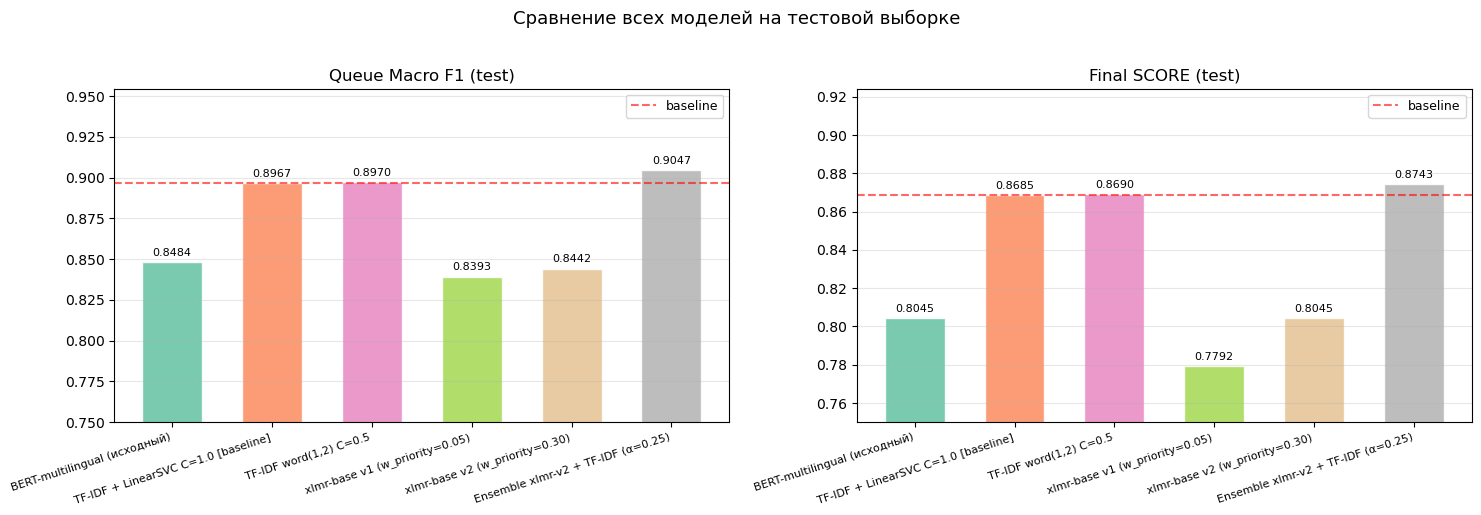

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
models = summary["name"].tolist()
x      = np.arange(len(models))
colors = plt.cm.Set2(np.linspace(0, 1, len(models)))

for ax, col, title in [
    (axes[0], "queue_macro_f1", "Queue Macro F1 (test)"),
    (axes[1], "score",          "Final SCORE (test)"),
]:
    vals = summary[col].fillna(0).values
    bars = ax.bar(x, vals, color=colors, alpha=0.87, edgecolor="white", width=0.6)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=18, ha="right", fontsize=8)
    ax.set_ylim(0.75, min(1.0, vals.max() + 0.05))
    ax.axhline(baseline_results[col], color="red", ls="--",
               alpha=0.6, lw=1.5, label="baseline")
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Сравнение всех моделей на тестовой выборке", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()